In [22]:
# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "diabetes_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [23]:
import pandas as pd
train_df = pd.read_csv('Diabetes-train.csv')
train_df.head()

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,343,1,0.0,68,35,No,32.0,0.389,22,No
1,496,6,166.0,74,No,No,26.6,0.304,66,No
2,1429,10,162.0,84,No,No,27.7,0.182,54,No
3,1722,0,84.0,82,31,125,38.2,0.233,23,No
4,1614,12,140.0,82,43,325,39.2,0.528,58,Yes


In [24]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        800 non-null    int64  
 1   Pregnancies               800 non-null    int64  
 2   Glucose                   799 non-null    float64
 3   BloodPressure             800 non-null    object 
 4   SkinThickness             799 non-null    object 
 5   Insulin                   800 non-null    object 
 6   BMI                       800 non-null    float64
 7   DiabetesPedigreeFunction  800 non-null    float64
 8   Age                       800 non-null    int64  
 9   Outcome                   800 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 62.6+ KB


In [25]:
train_df = train_df.dropna()

In [26]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 798 entries, 0 to 799
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        798 non-null    int64  
 1   Pregnancies               798 non-null    int64  
 2   Glucose                   798 non-null    float64
 3   BloodPressure             798 non-null    object 
 4   SkinThickness             798 non-null    object 
 5   Insulin                   798 non-null    object 
 6   BMI                       798 non-null    float64
 7   DiabetesPedigreeFunction  798 non-null    float64
 8   Age                       798 non-null    int64  
 9   Outcome                   798 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 68.6+ KB


In [27]:
train_df['Outcome'].value_counts()

Outcome
No     530
Yes    268
Name: count, dtype: int64

In [28]:
train_df[['BloodPressure', 'SkinThickness', 'Insulin']] = train_df[['BloodPressure', 'SkinThickness', 'Insulin']].replace('No', 0)
train_df['BloodPressure'] = train_df['BloodPressure'].replace("Don't Know", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("1No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("2No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("3No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("4No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("5No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("4.2cm", 4.2)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("3.5cm", 3.5)
train_df['Insulin'] = train_df['Insulin'].replace("22No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("5No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("14No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("12No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("24No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("16No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("51No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("18No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1NoNo", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1No5", 0)
train_df['Insulin'] = train_df['Insulin'].replace("4No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1No6", 0)
train_df['Insulin'] = train_df['Insulin'].replace("17No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("13No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("9No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("2No4", 0)
train_df['Insulin'] = train_df['Insulin'].replace("21No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("11No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("48No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1No8", 0)
train_df['Insulin'] = train_df['Insulin'].replace("3No4", 0)
train_df['Insulin'] = train_df['Insulin'].replace("2NoNo", 0)
train_df['Insulin'] = train_df['Insulin'].replace("19No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("15No", 0)
train_df[['BloodPressure', 'SkinThickness', 'Insulin']] = train_df[['BloodPressure', 'SkinThickness', 'Insulin']].astype('float')

In [29]:
train_df.dtypes

ID                            int64
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                      object
dtype: object

In [30]:
train_df.describe()

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,1390.008772,3.694236,120.917293,69.854637,18.158772,63.817043,32.272807,0.467989,33.047619
std,802.515323,3.252524,32.110196,19.100708,16.119596,100.789090,7.287515,0.309133,11.605832
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.084000,21.000000
25%,688.250000,1.000000,98.000000,64.000000,0.000000,0.000000,27.700000,0.241000,24.000000
50%,1378.500000,3.000000,117.000000,72.000000,19.000000,0.000000,32.300000,0.381500,29.000000
75%,2084.750000,6.000000,140.000000,80.000000,32.000000,103.750000,36.500000,0.619000,40.000000
max,2774.000000,17.000000,199.000000,122.000000,99.000000,545.000000,59.400000,2.420000,72.000000


Saving figure attribute_histogram_plots


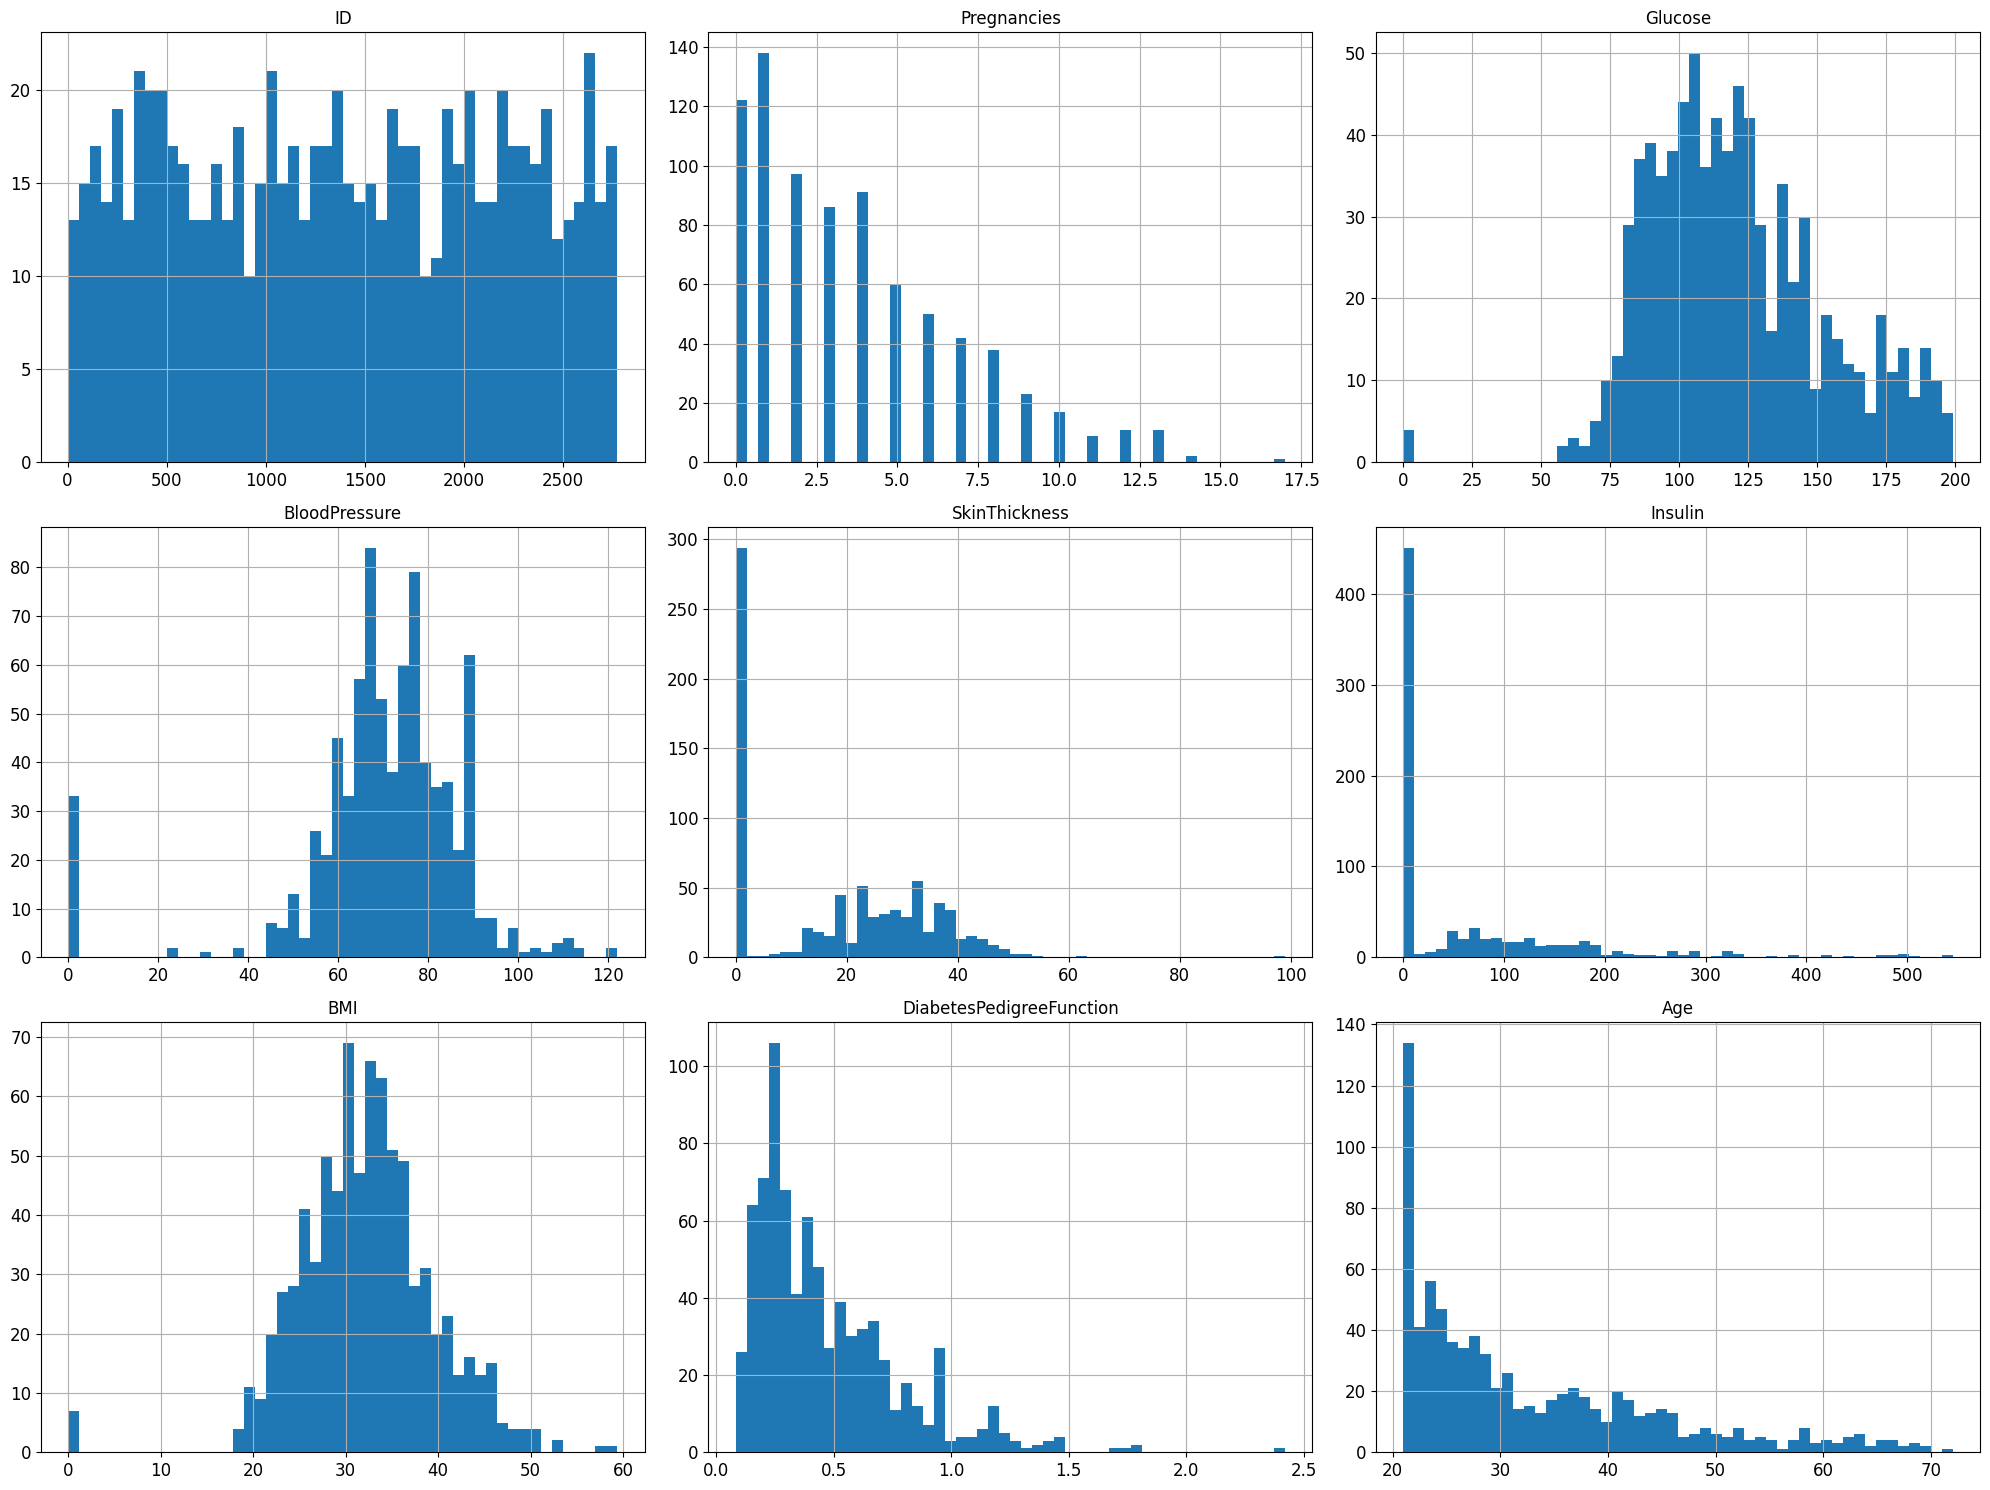

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
train_df.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

In [ ]:
train_df = train_df.drop('ID', axis=1)
train_df.head()

In [33]:
condition = train_df['BMI']==0
train_df[condition]

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
29,1140,0,118.0,64.0,23.0,89.0,0.0,1.731,21,No
174,2541,5,136.0,82.0,0.0,0.0,0.0,0.640,69,No
385,914,0,102.0,75.0,23.0,0.0,0.0,0.572,21,No
409,1665,0,94.0,0.0,0.0,0.0,0.0,0.256,25,No
426,146,0,102.0,75.0,23.0,0.0,0.0,0.572,21,No
570,1291,6,114.0,0.0,0.0,0.0,0.0,0.189,26,No
627,523,6,114.0,0.0,0.0,0.0,0.0,0.189,26,No


In [34]:
train_df = train_df.loc[~(train_df['BMI'] == 0)]
train_df.shape

(791, 10)

In [35]:
condition = train_df['BloodPressure']==0
train_df[condition]

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
32,469,8,120.0,0.0,0.0,0.0,30.0,0.183,38,Yes
141,644,4,90.0,0.0,0.0,0.0,28.0,0.610,31,No
154,348,3,116.0,0.0,0.0,0.0,23.5,0.187,23,No
160,1674,0,141.0,0.0,0.0,0.0,42.4,0.205,29,Yes
178,1466,0,99.0,0.0,0.0,0.0,25.0,0.253,22,No
199,1996,0,167.0,0.0,0.0,0.0,32.3,0.839,30,Yes
242,1199,2,99.0,0.0,0.0,0.0,22.2,0.108,23,No
246,1038,2,146.0,0.0,0.0,0.0,27.5,0.240,28,Yes
264,1869,4,90.0,0.0,0.0,0.0,28.0,0.610,31,No
279,2379,13,129.0,0.0,0.0,0.0,39.9,0.569,44,Yes


In [36]:
train_df = train_df.loc[~(train_df['BloodPressure'] == 0)]
train_df.shape

(761, 10)

In [37]:
train_df = train_df.replace(to_replace=["No"], value="0")
train_df = train_df.replace(to_replace=["Yes"], value="1")
train_df.head() 

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,343,1,0.0,68.0,35.0,0.0,32.0,0.389,22,0
1,496,6,166.0,74.0,0.0,0.0,26.6,0.304,66,0
2,1429,10,162.0,84.0,0.0,0.0,27.7,0.182,54,0
3,1722,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
4,1614,12,140.0,82.0,43.0,325.0,39.2,0.528,58,1


相關性矩陣


In [38]:
corr_matrix = train_df.corr()
corr_matrix

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
ID,1.000000,-0.030662,0.061504,0.048874,-0.004827,-0.104314,0.069950,-0.008493,0.046362,0.051224
Pregnancies,-0.030662,1.000000,0.155430,0.188124,-0.101273,-0.064781,0.045974,-0.035628,0.553513,0.232565
Glucose,0.061504,0.155430,1.000000,0.267935,0.103679,0.277479,0.206767,0.120181,0.300249,0.466631
BloodPressure,0.048874,0.188124,0.267935,1.000000,0.049828,-0.075138,0.313622,-0.016222,0.351342,0.171516
SkinThickness,-0.004827,-0.101273,0.103679,0.049828,1.000000,0.313631,0.327529,0.133302,-0.100563,0.105080
Insulin,-0.104314,-0.064781,0.277479,-0.075138,0.313631,1.000000,0.097257,0.169605,-0.055457,0.124923
BMI,0.069950,0.045974,0.206767,0.313622,0.327529,0.097257,1.000000,0.161960,0.064597,0.278219
DiabetesPedigreeFunction,-0.008493,-0.035628,0.120181,-0.016222,0.133302,0.169605,0.161960,1.000000,0.042603,0.144899
Age,0.046362,0.553513,0.300249,0.351342,-0.100563,-0.055457,0.064597,0.042603,1.000000,0.251345
Outcome,0.051224,0.232565,0.466631,0.171516,0.105080,0.124923,0.278219,0.144899,0.251345,1.000000


Saving figure corr_matrix_plots


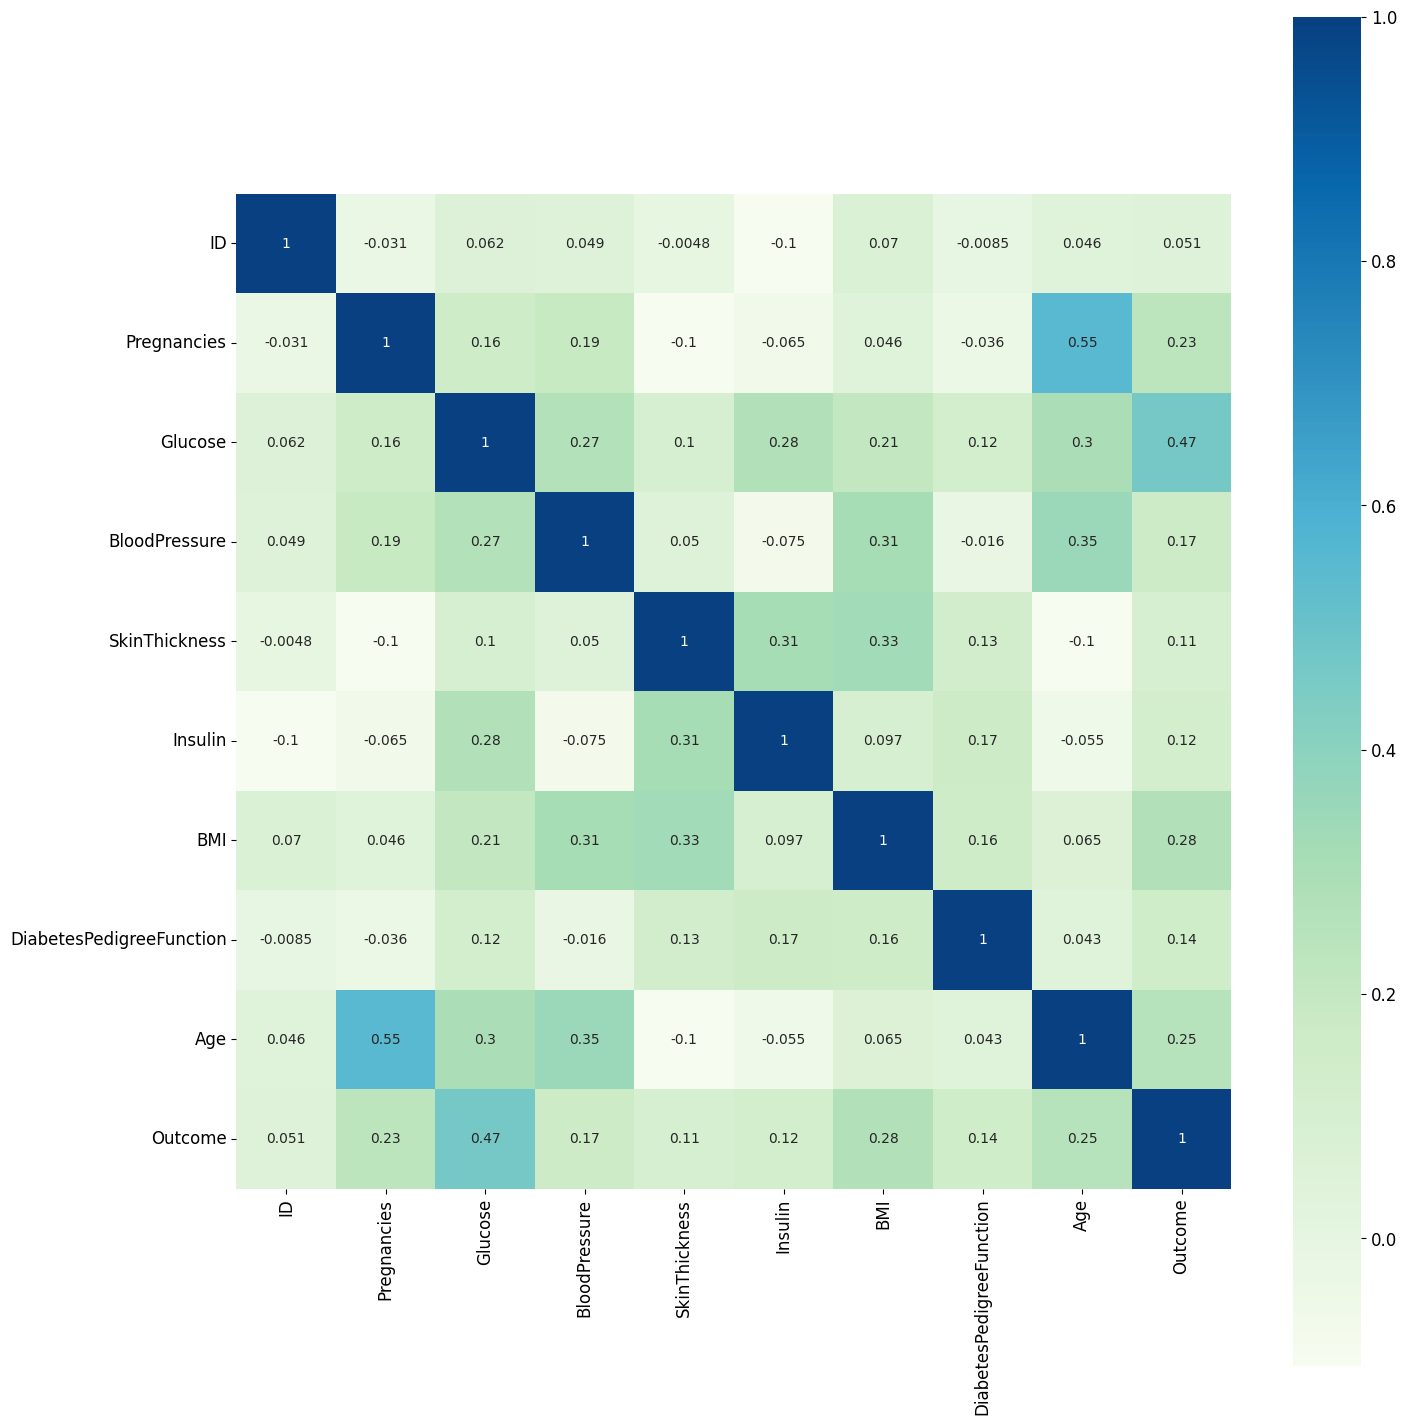

In [40]:
import seaborn as sns
plt.figure(figsize=(15,15))
ax = sns.heatmap(corr_matrix, square=True, annot=True, cmap='GnBu')
save_fig("corr_matrix_plots")
plt.show()

In [41]:
train_df = train_df.drop('ID', axis=1)
train_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,0.0,68.0,35.0,0.0,32.0,0.389,22,0
1,6,166.0,74.0,0.0,0.0,26.6,0.304,66,0
2,10,162.0,84.0,0.0,0.0,27.7,0.182,54,0
3,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
4,12,140.0,82.0,43.0,325.0,39.2,0.528,58,1


資料分割

In [42]:
from sklearn.model_selection import train_test_split
X = train_df.drop('Outcome', axis=1)
y = train_df['Outcome'].astype(int)
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(608, 8) (608,) (153, 8) (153,)


In [275]:
test_y

421    0
343    0
100    0
531    0
112    0
      ..
643    1
259    1
329    0
353    0
758    0
Name: Outcome, Length: 153, dtype: int64

Select and Train a Model

In [61]:
def threshold_predictions(predictions, threshold=0.5):
    """
    將預測結果轉換為二元分類的0或1，根據給定的閾值。

    Parameters:
    - predictions: 預測結果的列表或陣列
    - threshold: 閾值，預設為0.5

    Returns:
    - binary_predictions: 二元分類的0或1列表或陣列
    """
    binary_predictions = [1 if pred > threshold else 0 for pred in predictions]
    return binary_predictions

In [62]:
#LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

lin_reg = LinearRegression()
lin_reg.fit(train_X, train_y)
#pred1 = lin_reg.predict(test_X)
pred1 = threshold_predictions(lin_reg.predict(test_X))

lin_mse = mean_squared_error(test_y, pred1)
lin_rmse = np.sqrt(lin_mse)
lin_mae = mean_absolute_error(test_y, pred1)

print('MSE:',lin_mse)
print('MAE:',lin_mae)
print('Accuracy:',accuracy_score(test_y, pred1))



MSE: 0.20915032679738563
MAE: 0.20915032679738563
Accuracy: 0.7908496732026143


In [63]:
#決策樹
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(train_X, train_y)
pred2 = tree_reg.predict(test_X)

dt_mse = mean_squared_error(test_y, pred2)
dt_rmse = np.sqrt(dt_mse)
dt_mae = mean_absolute_error(test_y, pred2)

print('MSE:',dt_mse)
print('MAE:',dt_mae)
print('Accuracy:',accuracy_score(test_y, pred2))

MSE: 0.16339869281045752
MAE: 0.16339869281045752
Accuracy: 0.8366013071895425


In [64]:
#隨機森林
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg = forest_reg.fit(train_X, train_y)
#pred3 = forest_reg.predict(test_X)
pred3 = threshold_predictions(forest_reg.predict(test_X))

rf_mse = mean_squared_error(test_y, pred3)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(test_y, pred3)

print('MSE:',rf_mse)
print('MAE:',rf_mae)
print('Accuracy:',accuracy_score(test_y, pred3))

MSE: 0.11764705882352941
MAE: 0.11764705882352941
Accuracy: 0.8823529411764706


In [65]:
#支援向量機
from sklearn.svm import SVR
svm_reg = SVR(kernel="linear")
#svm_reg = SVR(kernel="rbf")  #accuracy:0.7777777
svm_reg.fit(train_X, train_y)
#pred4 = svm_reg.predict(test_X)
pred4 = threshold_predictions(svm_reg.predict(test_X))

rf_mse = mean_squared_error(test_y, pred4)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(test_y, pred4)

print('MSE:',rf_mse)
print('MAE:',rf_mae)
print('Accuracy:',accuracy_score(test_y, pred4))

MSE: 0.20261437908496732
MAE: 0.20261437908496732
Accuracy: 0.7973856209150327


In [66]:
#感知器
from sklearn.linear_model import Perceptron
per = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
per.fit(train_X, train_y)
pred5 = per.predict(test_X)

rf_mse = mean_squared_error(test_y, pred5)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(test_y, pred5)

print('MSE:',rf_mse)
print('MAE:',rf_mae)
print('Accuracy:',accuracy_score(test_y, pred5))

MSE: 0.2875816993464052
MAE: 0.2875816993464052
Accuracy: 0.7124183006535948


In [67]:
#神經網路
from sklearn.neural_network import MLPRegressor
mlp_reg = MLPRegressor(hidden_layer_sizes=(100,100),  max_iter=1000, tol=1e-3, random_state=42)
mlp_reg.fit(train_X, train_y)
#pred6 = mlp_reg.predict(test_X)
pred6 = threshold_predictions(mlp_reg.predict(test_X))

rf_mse = mean_squared_error(test_y, pred6)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(test_y, pred6)

print('MSE:',rf_mse)
print('MAE:',rf_mae)
print('Accuracy:',accuracy_score(test_y, pred6))

MSE: 0.26143790849673204
MAE: 0.26143790849673204
Accuracy: 0.738562091503268


Cross-Validation

In [68]:
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [69]:
#線性回歸
lin_scores = cross_val_score(lin_reg, train_X, train_y,
                         scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [0.42485785 0.42392608 0.4121922  0.38616938 0.44332661 0.39282654
 0.42159919 0.39210324 0.43259814 0.35518517]
Mean: 0.4084784405396819
Standard deviation: 0.02517937979741639


In [70]:
#決策樹
tree_scores = cross_val_score(tree_reg, train_X, train_y,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)
display_scores(tree_rmse_scores)

Scores: [0.31362502 0.40488817 0.40488817 0.28629917 0.46164354 0.42465029
 0.40488817 0.52790958 0.34156503 0.40824829]
Mean: 0.39786054082662875
Standard deviation: 0.06683227434909378


In [71]:
#隨機森林
rf_scores = cross_val_score(forest_reg, train_X, train_y,
                         scoring="neg_mean_squared_error", cv=10)
rf_rmse_scores = np.sqrt(-rf_scores)
display_scores(rf_rmse_scores)

Scores: [0.33196632 0.30761377 0.27590091 0.26490332 0.37746784 0.34413589
 0.33206507 0.3274842  0.30435177 0.29650745]
Mean: 0.3162396535609366
Standard deviation: 0.03165284000980185


In [72]:
#支援向量機
svm_scores = cross_val_score(svm_reg, train_X, train_y,
                         scoring="neg_mean_squared_error", cv=10)
svm_rmse_scores = np.sqrt(-svm_scores)
display_scores(svm_rmse_scores)

Scores: [0.4378913  0.44440415 0.39978524 0.40771018 0.469114   0.40029049
 0.44419696 0.39541233 0.45673965 0.3671886 ]
Mean: 0.4222732906219184
Standard deviation: 0.03090825351903143


In [73]:
#感知器
per_scores = cross_val_score(per, train_X, train_y,
                         scoring="neg_mean_squared_error", cv=10)
per_rmse_scores = np.sqrt(-per_scores)
display_scores(per_rmse_scores)

Scores: [0.70128687 0.70128687 0.73551588 0.79959006 0.54321448 0.52790958
 0.57259833 0.55809982 0.78528127 0.53229065]
Mean: 0.6457073807942727
Standard deviation: 0.10376365654981037


In [74]:
#神經網路
mlp_scores = cross_val_score(mlp_reg, train_X, train_y,
                         scoring="neg_mean_squared_error", cv=10)
mlp_rmse_scores = np.sqrt(-mlp_scores)
display_scores(mlp_rmse_scores)

Scores: [0.49734783 0.69299411 0.46176742 0.50080182 0.48970221 0.52742263
 0.4419089  0.50152727 0.45527875 0.60473411]
Mean: 0.5173485042417509
Standard deviation: 0.07273967550091401


Analyzing the Best Models

In [76]:
feature_names = X.columns
coefficients = lin_reg.coef_
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")

Pregnancies: 0.015067712450436779
Glucose: 0.005319843038919193
BloodPressure: -0.0017630100569067297
SkinThickness: 0.0009714596676330834
Insulin: 3.6147548928237735e-05
BMI: 0.013838231150440214
DiabetesPedigreeFunction: 0.12554547182035491
Age: 0.0035747283583061743


Saving figure feature_importance(tree)


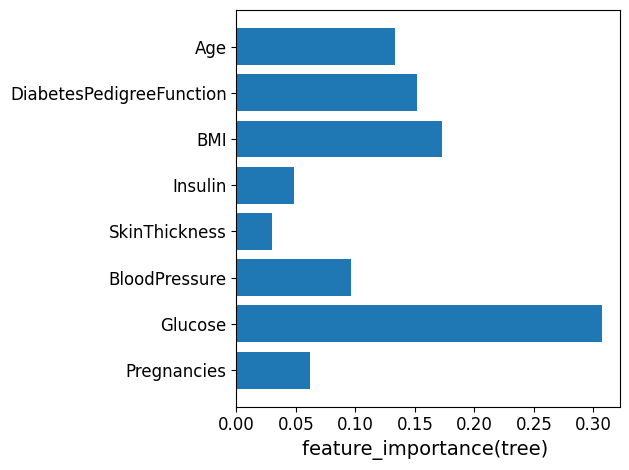

In [77]:
# 獲取特徵重要性
feature_importance = tree_reg.feature_importances_

# 創建條形圖

plt.barh(range(len(feature_importance)), feature_importance, align='center')
plt.yticks(range(len(feature_importance)), feature_names)  # 假設 feature_names 是特徵名稱
plt.xlabel('feature_importance(tree) ')
save_fig("feature_importance(tree)")
plt.show()

Saving figure feature_importance(forest)


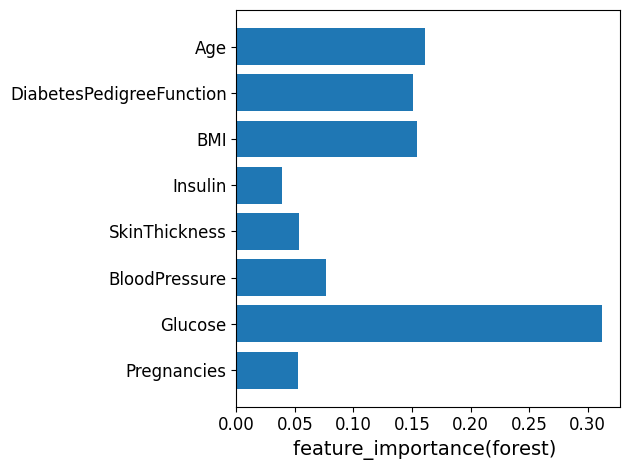

In [78]:
# 獲取特徵重要性
feature_importance_forest = forest_reg.feature_importances_

# 創建條形圖
plt.barh(range(len(feature_importance_forest)), feature_importance_forest, align='center')
plt.yticks(range(len(feature_importance_forest)), feature_names)  # 假設 feature_names 是特徵名稱
plt.xlabel('feature_importance(forest) ')
save_fig("feature_importance(forest)")
plt.show()

In [83]:
svm_reg.coef_

array([[0.02661157, 0.00753488, 0.0009243 , 0.00156372, 0.00016559,
        0.01015928, 0.12544994, 0.00070351]])

In [294]:
per.coef_

array([[ 811.  ,  290.  , -686.  ,  253.2 , -156.  ,  206.  ,   61.45,
         113.  ]])

In [295]:
mlp_reg.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100, 100),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 1000,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': 42,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

Evaluate System on the Test Data

In [86]:
test = pd.read_csv('Diabetes-test.csv')

In [87]:
test[['BloodPressure', 'SkinThickness', 'Insulin']] = test[['BloodPressure', 'SkinThickness', 'Insulin']].replace('No', 0)
test['BloodPressure'] = test['BloodPressure'].replace("Don't Know", 0)
test['BloodPressure'] = test['BloodPressure'].replace("4No", 0)
test['SkinThickness'] = test['SkinThickness'].replace("2No", 0)
test['SkinThickness'] = test['SkinThickness'].replace("4No", 0)
test['SkinThickness'] = test['SkinThickness'].replace("1No", 0)
test['SkinThickness'] = test['SkinThickness'].replace("3No", 0)
test['SkinThickness'] = test['SkinThickness'].replace("2.3cm", 2.3)
test['Insulin'] = test['Insulin'].replace("5No", 0)
test['Insulin'] = test['Insulin'].replace("13No", 0)
test['Insulin'] = test['Insulin'].replace("11No", 0)
test['Insulin'] = test['Insulin'].replace("13No", 0)
test['Insulin'] = test['Insulin'].replace("12No", 0)
test['Insulin'] = test['Insulin'].replace("16No", 0)
test['Insulin'] = test['Insulin'].replace("21No", 0)
test['Insulin'] = test['Insulin'].replace("1No5", 0)
test['Insulin'] = test['Insulin'].replace("18No", 0)
test['Insulin'] = test['Insulin'].replace("14No", 0)
test[['BloodPressure', 'SkinThickness', 'Insulin']] = test[['BloodPressure', 'SkinThickness', 'Insulin']].astype('float')

In [88]:
test = test.drop('ID', axis=1)

In [89]:
test = test.fillna(0)

In [92]:
output = pd.DataFrame()
y_pred = threshold_predictions(forest_reg.predict(test))
output['Outcome'] = y_pred
output.to_csv('Diabetes-output.csv')

In [91]:
Diabetes-output.head()

,Outcome
0,0
1,0
2,0
3,0
4,1
